#1) Data Cleansing

In [1]:
# --- Step 1: Import Libraries ---
import pandas as pd
import numpy as np
from google.colab import files

# --- Step 2: Upload the Dataset ---
uploaded = files.upload()  # This will prompt you to upload the file

# Get the uploaded file name
filename = list(uploaded.keys())[0]
print(f"Uploaded file: {filename}")

# Load the dataset
df = pd.read_csv(filename)
print("Dataset Loaded Successfully!")
print(df.head())

# --- Step 3: Data Cleansing ---

# 3.1 Remove duplicate rows
df = df.drop_duplicates()
print("Duplicates removed. Dataset shape:", df.shape)

# 3.2 Handle missing values

# Fill missing numeric columns with median
num_cols = df.select_dtypes(include=['int64','float64']).columns
for col in num_cols:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)
    print(f"Filled missing values in {col} with median: {median_value}")

# Fill missing categorical columns with mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    mode_value = df[col].mode()[0]
    df[col] = df[col].fillna(mode_value)
    print(f"Filled missing values in {col} with mode: {mode_value}")

# 3.3 Handle outliers using IQR method
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers_lower = (df[col] < lower).sum()
    outliers_upper = (df[col] > upper).sum()
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])
    print(f"Outliers capped in {col}: lower={outliers_lower}, upper={outliers_upper}")

print("✅ Data Cleansing Completed!")


Saving microsoft_loan.csv to microsoft_loan.csv
Uploaded file: microsoft_loan.csv
Dataset Loaded Successfully!
   memberId residentialState yearsEmployment homeOwnership  annualIncome  \
0   2305095               NM       10+ years          rent         56471   
1   2610493               WA       2-5 years          rent         55038   
2   2491679               MS        < 1 year          rent         56610   
3   2092798               TX       6-9 years           own         54887   
4   2633077               MA       2-5 years          rent         53522   

   incomeVerified  dtiRatio  lengthCreditHistory  numTotalCreditLines  \
0               1     16.80                    6                   11   
1               0     19.99                   22                    8   
2               1     14.33                    5                    8   
3               1     14.80                   12                   14   
4               1     10.14                    4                   

#2)Imputation


In [2]:
from sklearn.impute import SimpleImputer

# --- Check missing values BEFORE imputation ---
print("Missing values BEFORE imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# --- 3.1 Impute numeric columns with median ---
num_cols = df.select_dtypes(include=['int64','float64']).columns
num_imputer = SimpleImputer(strategy='median')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

print("\nMissing numeric values imputed with median.")

# --- 3.2 Impute categorical columns with mode ---
cat_cols = df.select_dtypes(include=['object']).columns
cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

print("Missing categorical values imputed with mode.")

# --- Check missing values AFTER imputation ---
print("\nMissing values AFTER imputation:")
missing = df.isnull().sum()
print(missing[missing > 0] if not missing[missing > 0].empty else "✅ No missing values remain!")

# --- Optionally: Display rows where missing values were present before ---
print("\nExample rows where missing numeric values were present:")
print(df.loc[df[num_cols].isnull().any(axis=1)].head())


Missing values BEFORE imputation:
Series([], dtype: int64)

Missing numeric values imputed with median.
Missing categorical values imputed with mode.

Missing values AFTER imputation:
✅ No missing values remain!

Example rows where missing numeric values were present:
Empty DataFrame
Columns: [memberId, residentialState, yearsEmployment, homeOwnership, annualIncome, incomeVerified, dtiRatio, lengthCreditHistory, numTotalCreditLines, numOpenCreditLines, numOpenCreditLines1Year, revolvingBalance, revolvingUtilizationRate, numDerogatoryRec, numDelinquency2Years, numChargeoff1year, numInquiries6Mon]
Index: []


#3)Encoding

In [14]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# --- Load dataset ---
df = pd.read_csv(filename, nrows=10000)

print("Sample dataset loaded:", df.shape)

# --- Identify categorical columns ---
cat_cols = df.select_dtypes(include=['object']).columns

df_encoded = df.copy()

# --- Encoding ---
for col in cat_cols:
    unique_count = df[col].nunique()
    if unique_count > 50:
        # 🔹 Label Encoding for high-cardinality
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df[col].astype(str))
        print(f"Label Encoded: {col} ({unique_count} unique values)")
    else:
        # 🔹 One-Hot Encoding for low-cardinality
        df_encoded = pd.get_dummies(df_encoded, columns=[col], drop_first=True)
        print(f"One-Hot Encoded: {col} ({unique_count} unique values)")

print("✅ Final Encoding Completed!")
print("Shape after encoding:", df_encoded.shape)


Sample dataset loaded: (10000, 17)
One-Hot Encoded: residentialState (49 unique values)
One-Hot Encoded: yearsEmployment (5 unique values)
One-Hot Encoded: homeOwnership (3 unique values)
✅ Final Encoding Completed!
Shape after encoding: (10000, 68)


#4)Data Transformation

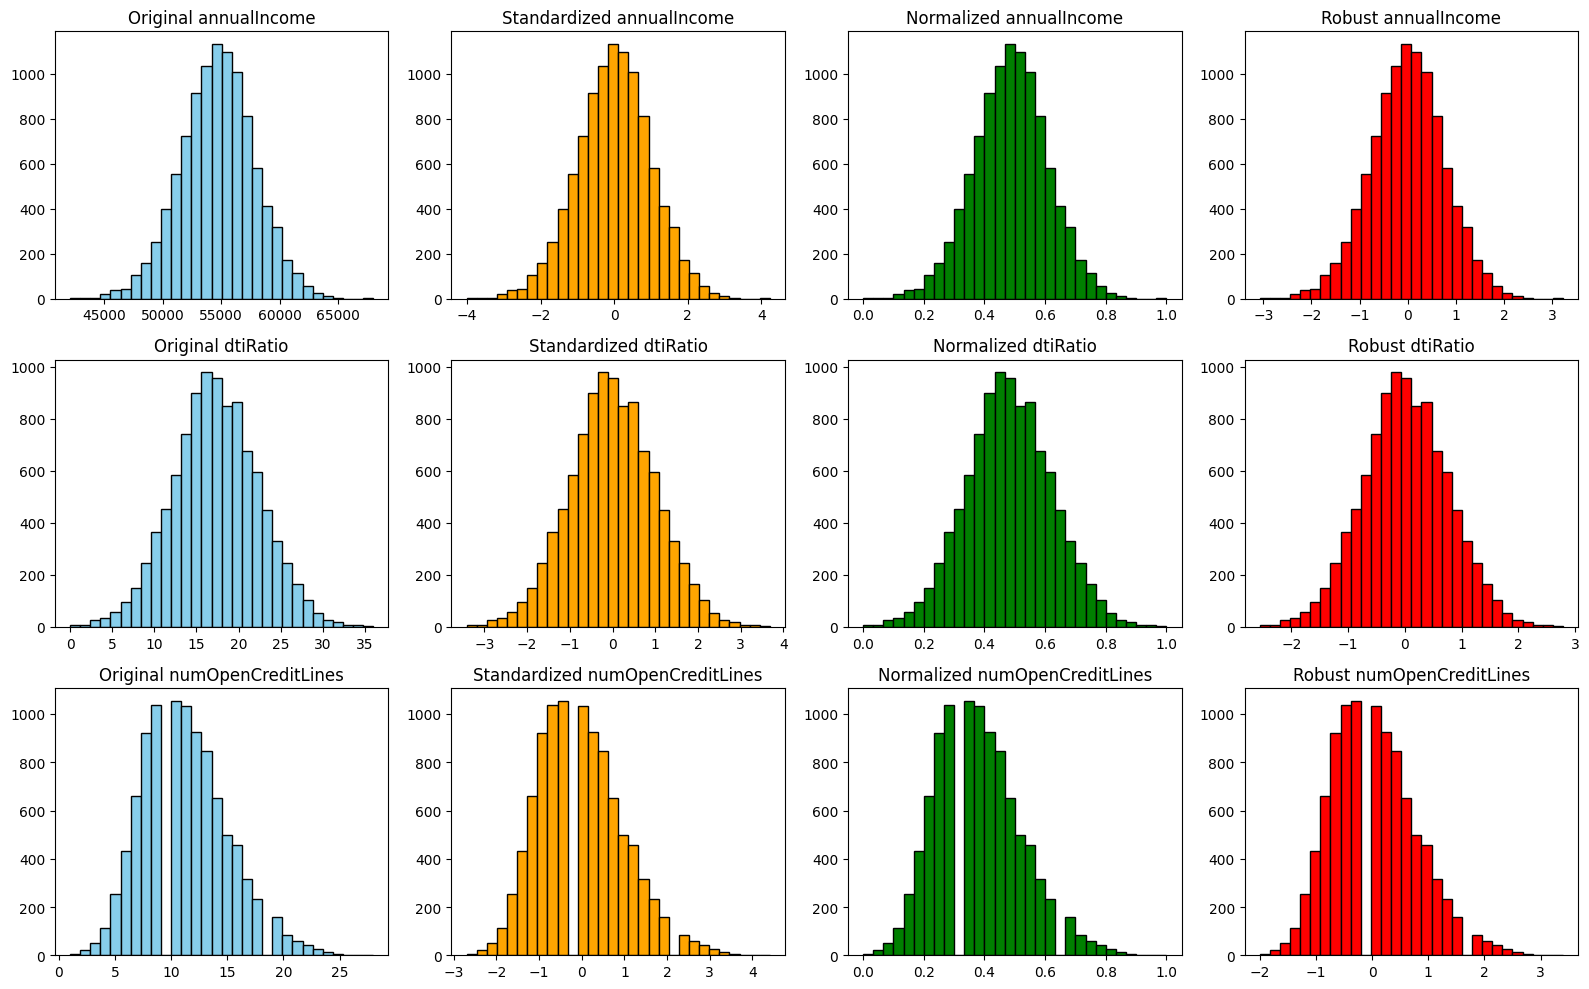

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
import numpy as np

# --- Load dataset (first 10000 rows) ---
df = pd.read_csv("microsoft_loan.csv", nrows=10000)

# Select numeric columns automatically
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# --- Apply different scalers ---
scaler_std = StandardScaler()
scaler_minmax = MinMaxScaler()
scaler_robust = RobustScaler()

df_std = pd.DataFrame(scaler_std.fit_transform(df[num_cols]), columns=num_cols)
df_minmax = pd.DataFrame(scaler_minmax.fit_transform(df[num_cols]), columns=num_cols)
df_robust = pd.DataFrame(scaler_robust.fit_transform(df[num_cols]), columns=num_cols)

# --- Choose a few important numeric features from your dataset ---
cols_to_plot = ["annualIncome", "dtiRatio", "numOpenCreditLines"]  # update based on your columns

# --- Plot histograms ---
fig, axes = plt.subplots(len(cols_to_plot), 4, figsize=(16, 10))

for i, col in enumerate(cols_to_plot):
    # Original
    axes[i,0].hist(df[col].dropna(), bins=30, color="skyblue", edgecolor="black")
    axes[i,0].set_title(f"Original {col}")

    # Standardized
    axes[i,1].hist(df_std[col], bins=30, color="orange", edgecolor="black")
    axes[i,1].set_title(f"Standardized {col}")

    # Normalized (MinMax)
    axes[i,2].hist(df_minmax[col], bins=30, color="green", edgecolor="black")
    axes[i,2].set_title(f"Normalized {col}")

    # Robust
    axes[i,3].hist(df_robust[col], bins=30, color="red", edgecolor="black")
    axes[i,3].set_title(f"Robust {col}")

plt.tight_layout()
plt.show()


#5)Data Splitting

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load dataset
file_path = "microsoft_loan.csv"
df = pd.read_csv(file_path)

# Features (X) → drop target and ID column
X = df.drop(["numChargeoff1year", "memberId"], axis=1)

# Target (y) → charge-offs in 1 year
y = df["numChargeoff1year"]

# Split into train (70%), test (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("✅ Data Splitting Completed!")
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


✅ Data Splitting Completed!
Training set shape: (70000, 15)
Testing set shape: (30000, 15)


#6)Data Reduction

In [12]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# --- Load dataset (sample 100 rows for testing) ---
df = pd.read_csv("microsoft_loan.csv", nrows=100)

# One-hot encode categorical columns
cat_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Separate features and target (use numChargeoff1year as target)
X = df_encoded.drop(["numChargeoff1year", "memberId"], axis=1)
y = df_encoded["numChargeoff1year"]

# --- Handle missing values ---
imputer = SimpleImputer(strategy="median")   # for numeric, median works well
X_imputed = imputer.fit_transform(X)

# --- Standardize before PCA ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# --- Apply PCA with explained variance threshold ---
pca = PCA(n_components=0.95)  # retain 95% variance
X_reduced = pca.fit_transform(X_scaled)

print("✅ Data Reduction with PCA Completed!")
print("Original shape:", X.shape)
print("Reduced shape :", X_reduced.shape)

# Explained variance
explained_var = pca.explained_variance_ratio_.sum()
print(f"Variance retained: {explained_var:.2%}")


✅ Data Reduction with PCA Completed!
Original shape: (100, 61)
Reduced shape : (100, 46)
Variance retained: 95.10%


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# --- Accuracy block (run after PCA code) ---
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"🎯 Model Accuracy after PCA: {accuracy:.4f}")


🎯 Model Accuracy after PCA: 0.7000
